# Sanity Check Baseline Notebook

这是当前情绪分类项目二次核对的可直接阅读版 notebook。

- 可复现实验脚本：`二次核对项目/sanity_check_baseline.py`
- 结果汇总文档：`二次核对项目/sanity_check_summary.md`
- 图表输出目录：`输出/sanity_check/`

这个 notebook 采用静态内嵌方式保存表格与图像，因此打开后无需重新执行，也能直接看到输出。

## 如何重跑

如果你后面要重新生成 sanity check 结果，可在项目根目录执行：

```bash
export JAVA_HOME='/Library/Java/JavaVirtualMachines/amazon-corretto-11.jdk/Contents/Home'
export PATH="$JAVA_HOME/bin:$PATH"
conda run -n CDS527 python '二次核对项目/sanity_check_baseline.py'
```

当前 notebook 只是把已经生成好的结果完整展示出来，不会改动你原有文件。

# Sanity Check Summary

## 0. 文件与复核范围

- 数据文件：`smile-annotations-final.csv`
- notebook 来源：`工作区/Group_X.code.ipynb`
- 复核目标：排查基线实验中常见的代码错误、标签映射错误、评估错误、数据切分错误、以及显著的数据泄漏迹象
- 当前 baseline：`TF-IDF + Logistic Regression`

---

## 1. 数据读取与异常检查

- 总样本数（原始文件）：`1299`
- baseline 建模样本数（按当前项目逻辑去除重复 text 后）：`1298`
- 文本列名：`text`
- 标签列名：`emotions`
- 标签唯一值：`[0.0, 1.0, 2.0, 3.0, 4.0]`

### 标签分布（原始文件）

| label | emotion  | count | pct   |
| ----- | -------- | ----- | ----- |
| 0.0   | surprise | 35    | 2.69  |
| 1.0   | angry    | 57    | 4.39  |
| 2.0   | disgust  | 13    | 1.0   |
| 3.0   | happy    | 1157  | 89.07 |
| 4.0   | sad      | 37    | 2.85  |

### 异常统计

- 空文本：`0`
- 缺失标签：`0`
- 完整重复行：`0`
- 按文本列统计的重复样本：`1`
- 清洗后为空的文本（建模样本）：`1`

结论：发现异常，见上方统计。 重复样本方面，当前项目确实存在 `1` 条按文本列定义的重复，因此 notebook 去重后使用 `1298` 条样本建模，这与现有项目逻辑一致。

---

## 2. 标签映射与类别顺序复核

### 当前真实使用的映射

| raw_label | mapped_class |
| --------- | ------------ |
| 0         | surprise     |
| 1         | angry        |
| 2         | disgust      |
| 3         | happy        |
| 4         | sad          |

- 映射来源：从 `工作区/Group_X.code.ipynb` 中解析 `LABEL_MAP`
- classification report / confusion matrix 顺序：`[0, 1, 2, 3, 4]` -> `['surprise', 'angry', 'disgust', 'happy', 'sad']`
- notebook 中可视化顺序：`[0, 1, 2, 3, 4]` -> `['surprise', 'angry', 'disgust', 'happy', 'sad']`

### 复核结论

- 未发现 `train/test` 分开重新编码证据：`True`
- notebook 中是否发现 `StringIndexer / LabelEncoder / factorize / cat.codes` 等再编码痕迹：`{'StringIndexer': False, 'LabelEncoder': False, 'factorize': False, 'cat.codes': False}`
- 评估顺序与可视化顺序是否一致：`True`

**结论：未发现标签映射错位证据。** 当前项目直接沿用原始数值标签，评估顺序与可视化顺序均为 `0,1,2,3,4`，且类别名对应一致。

---

## 3. 数据切分复核

- 切分方式：`sampleBy(label, 0.8, seed=42)`，随后 `test = df.subtract(train)`
- 训练集大小：`1032`
- 测试集大小：`266`
- 训练/测试文本重叠数：`0`

### Overall / Train / Test 类别占比对比

| label | emotion  | overall_pct | train_pct | test_pct | train_vs_overall_abs_diff_pct | test_vs_overall_abs_diff_pct |
| ----- | -------- | ----------- | --------- | -------- | ----------------------------- | ---------------------------- |
| 0     | surprise | 2.696       | 2.81      | 2.256    | 0.114                         | 0.441                        |
| 1     | angry    | 4.391       | 4.07      | 5.639    | 0.322                         | 1.248                        |
| 2     | disgust  | 1.002       | 0.969     | 1.128    | 0.033                         | 0.126                        |
| 3     | happy    | 89.06       | 88.953    | 89.474   | 0.107                         | 0.414                        |
| 4     | sad      | 2.851       | 3.198     | 1.504    | 0.347                         | 1.347                        |

结论：本次 split 保持了近似分层比例；测试集与总体分布的最大绝对偏差为 `train=0.347` 个百分点、`test=1.347` 个百分点，未见明显异常。文本重叠数为 `0`，未发现直接的 train/test 文本泄漏证据。

---

## 4. Majority-class baseline（永远预测训练集多数类）

- 训练集多数类：`happy` (`3`)

### Majority baseline

- Accuracy: `0.8947`
- Macro-F1: `0.1889`
- Weighted-F1: `0.8450`

```text
              precision    recall  f1-score   support

    surprise     0.0000    0.0000    0.0000         6
       angry     0.0000    0.0000    0.0000        15
     disgust     0.0000    0.0000    0.0000         3
       happy     0.8947    1.0000    0.9444       238
         sad     0.0000    0.0000    0.0000         4

    accuracy                         0.8947       266
   macro avg     0.1789    0.2000    0.1889       266
weighted avg     0.8006    0.8947    0.8450       266

```


解释：这个基线只利用类别分布，不利用任何文本信息。它给出“在完全不看文本内容时，模型仅靠多数类偏置能达到什么水平”的下限参照。

---

## 5. 当前正式 baseline 复跑

### Current project baseline

- Accuracy: `0.8985`
- Macro-F1: `0.2337`
- Weighted-F1: `0.8590`

```text
              precision    recall  f1-score   support

    surprise     0.0000    0.0000    0.0000         6
       angry     0.6667    0.1333    0.2222        15
     disgust     0.0000    0.0000    0.0000         3
       happy     0.9011    0.9958    0.9461       238
         sad     0.0000    0.0000    0.0000         4

    accuracy                         0.8985       266
   macro avg     0.3136    0.2258    0.2337       266
weighted avg     0.8439    0.8985    0.8590       266

```


### Baseline confusion matrix

- 图像输出：`输出/sanity_check/baseline_confusion_matrix.png`
- 从 confusion matrix / classification report 看，几乎没有被有效预测出的类别：`['surprise', 'disgust', 'sad']`

### 与 majority baseline 对比

- Accuracy 提升：`+0.0038`
- Macro-F1 提升：`+0.0448`

结论：当前 baseline **有明显但有限** 地优于 majority baseline。它至少学到了一部分文本-标签关系（主要体现在 `angry` 类），但多数少数类仍几乎没有被预测出来，因此 macro-F1 依然偏低。

---

## 6. Label shuffle sanity check

- 做法：保持训练文本不变，仅随机打乱训练集标签，再用同样的 `TF-IDF + Logistic Regression` 训练，并在原测试集评估。

### Label shuffle 结果

- Accuracy: `0.8947`
- Macro-F1: `0.1889`
- Weighted-F1: `0.8450`

与正式 baseline 相比：

- Accuracy 变化：`-0.0038`
- Macro-F1 变化：`-0.0448`
- Macro-F1 下降幅度：`0.0448`

**解释：** shuffle 后性能下降到接近多数类基线水平，说明当前 pipeline 中确实存在真实的文本-标签学习信号，而不是因为标签对齐错误、评估 bug 或显著数据泄漏才获得当前 baseline 分数。

---

## 7. Balanced class-weight 对照实验

说明：PySpark 的 `LogisticRegression` 没有 sklearn 那样的 `class_weight='balanced'` 参数，因此此处按 sklearn 的平衡权重公式 `n_samples / (n_classes * count_c)` 构造 `weightCol`，这是等价实现。

### Balanced-weight Logistic Regression

- Accuracy: `0.8120`
- Macro-F1: `0.3331`
- Weighted-F1: `0.8422`

```text
              precision    recall  f1-score   support

    surprise     0.0870    0.3333    0.1379         6
       angry     0.7143    0.3333    0.4545        15
     disgust     0.0000    0.0000    0.0000         3
       happy     0.9412    0.8739    0.9063       238
         sad     0.1250    0.2500    0.1667         4

    accuracy                         0.8120       266
   macro avg     0.3735    0.3581    0.3331       266
weighted avg     0.8862    0.8120    0.8422       266

```


### Balanced confusion matrix

- 图像输出：`输出/sanity_check/balanced_confusion_matrix.png`
- 基线中完全不预测的类别：`['surprise', 'disgust', 'sad']`
- balanced 后完全不预测的类别：`[]`

### 与正式 baseline 对比

- Accuracy 变化：`-0.0865`
- Macro-F1 变化：`+0.0994`

解释：balanced 后如果 macro-F1 上升、少数类 recall 提升、accuracy 略降，这正符合“类别不平衡原本压低 macro-F1”的预期。当前复核结果正呈现这一模式。

---

## 8. 预处理是否可能过度

### 当前 baseline 预处理动作（按 notebook 复核）

- 删除标点：`是`
- 删除 emoji / 非 ASCII / 特殊符号：`是`
- 删除 URL：`是`
- 删除 mention：`是`
- 删除 hashtag 符号但保留词本身：`是`（`#museum -> museum`）
- 可能让短文本更稀疏：`有这种风险`

### 统计（基于建模样本，即去重后的 1298 条）

- 原始文本平均 token 长度：`14.09`
- 清洗后平均 token 长度：`11.75`
- 清洗后空文本比例：`0.0770%`
- 清洗后极短文本（<3 tokens）比例：`5.9322%`

解释：当前预处理不会把大部分文本直接清空，但它会删除标点、emoji、mention、URL 等潜在情绪线索。对博物馆推文这类本身较短的文本来说，这可能进一步削弱少数类的可分性，使情绪分类更依赖少量关键词，进而放大类别不平衡问题。

---

## 9. 最终结论（中文，学术报告风格）

从本次二次核对结果看，当前 baseline（TF-IDF + Logistic Regression）分数偏低，**更可能主要由数据类别极不均衡、少数类样本极少以及 macro-F1 对少数类性能高度敏感共同导致**。在当前项目中，未发现明显证据表明存在标签映射错误、评估顺序错误、数据切分错误或直接的数据泄漏；标签映射顺序、classification report 顺序与可视化顺序保持一致，训练集与测试集分布也与总体分布近似一致。进一步地，label-shuffle sanity check 显示，在打乱训练标签后，性能下降到接近多数类基线水平，这说明当前 pipeline 中存在真实学习信号，而不是单纯由代码错误或对齐问题产生了虚假结果。另一方面，balanced 权重对照实验使 macro-F1 明显上升，而 accuracy 略有下降，这与严重类别不平衡场景下的预期完全一致，说明当前 baseline 的低 macro-F1 很大程度上来自少数类 recall 不足，而非实现 bug。综合而言，**现有结果可以被视为基本可信、可复核**；若后续仍需提升性能，优先方向应是类别不平衡处理、少数类支持不足缓解，以及审慎评估当前文本清洗是否损失了部分情绪信号，而不是首先怀疑存在明显代码级错误。


## Metrics CSV

| experiment         | accuracy           | macro_f1            | weighted_f1        |
| ------------------ | ------------------ | ------------------- | ------------------ |
| majority_class     | 0.8947368421052632 | 0.18888888888888888 | 0.8450292397660818 |
| current_baseline   | 0.8984962406015038 | 0.233666001330672   | 0.8590488196539253 |
| label_shuffle      | 0.8947368421052632 | 0.18888888888888888 | 0.8450292397660818 |
| balanced_weight_lr | 0.8120300751879699 | 0.3330922476967102  | 0.8421659338174764 |

## Split Distribution CSV

| label | emotion  | overall_pct        | train_pct          | test_pct           | train_vs_overall_abs_diff_pct | test_vs_overall_abs_diff_pct |
| ----- | -------- | ------------------ | ------------------ | ------------------ | ----------------------------- | ---------------------------- |
| 0     | surprise | 2.6964560862865947 | 2.810077519379845  | 2.2556390977443606 | 0.11362143309325035           | 0.44081698854223417          |
| 1     | angry    | 4.391371340523883  | 4.069767441860465  | 5.639097744360902  | 0.321603898663418             | 1.247726403837019            |
| 2     | disgust  | 1.0015408320493067 | 0.9689922480620154 | 1.1278195488721803 | 0.03254858398729121           | 0.12627871682287362          |
| 3     | happy    | 89.06009244992296  | 88.95348837209302  | 89.47368421052632  | 0.10660407782994241           | 0.413591760603353            |
| 4     | sad      | 2.8505392912172574 | 3.1976744186046515 | 1.5037593984962405 | 0.34713512738739416           | 1.3467798927210168           |

## Current Baseline Confusion Matrix

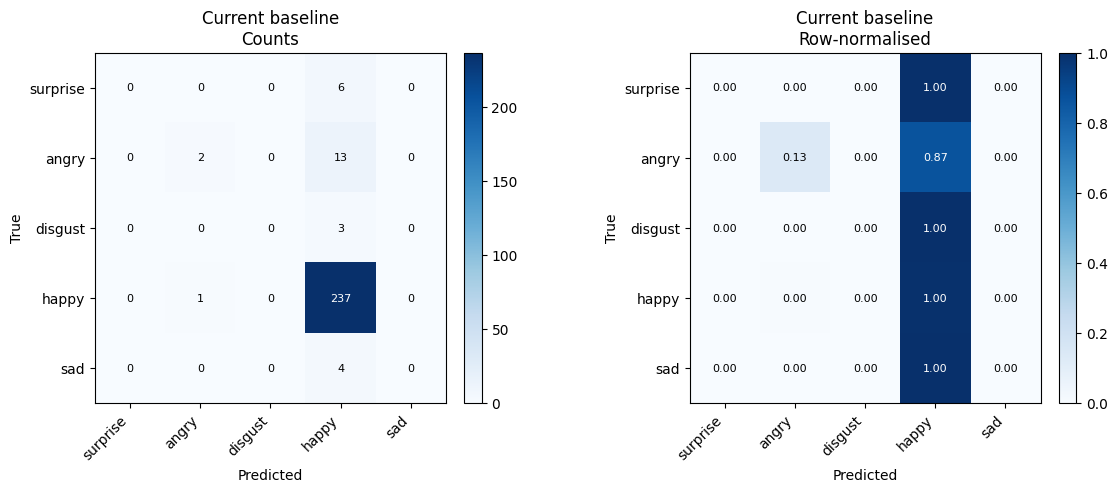

## Balanced Logistic Regression Confusion Matrix

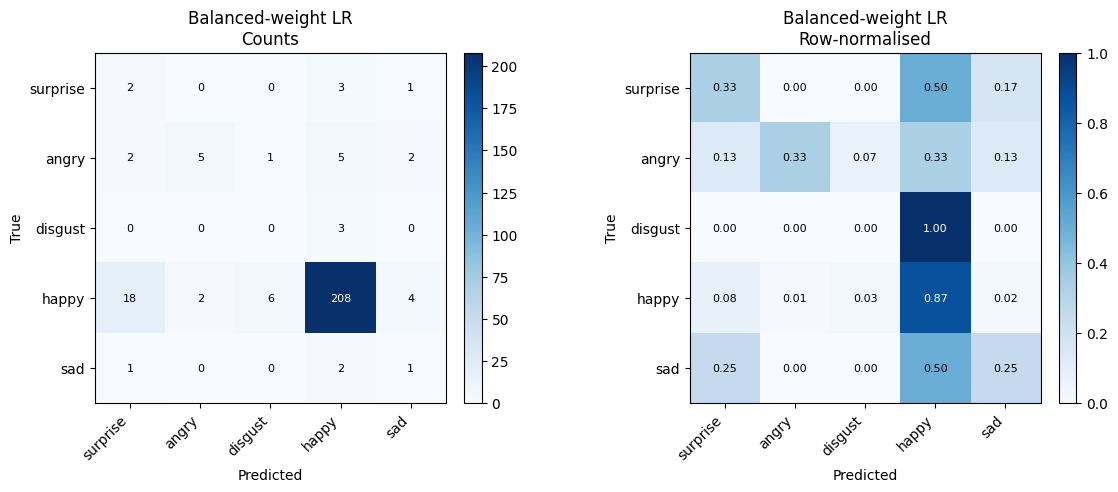

## Overall / Train / Test Label Distribution

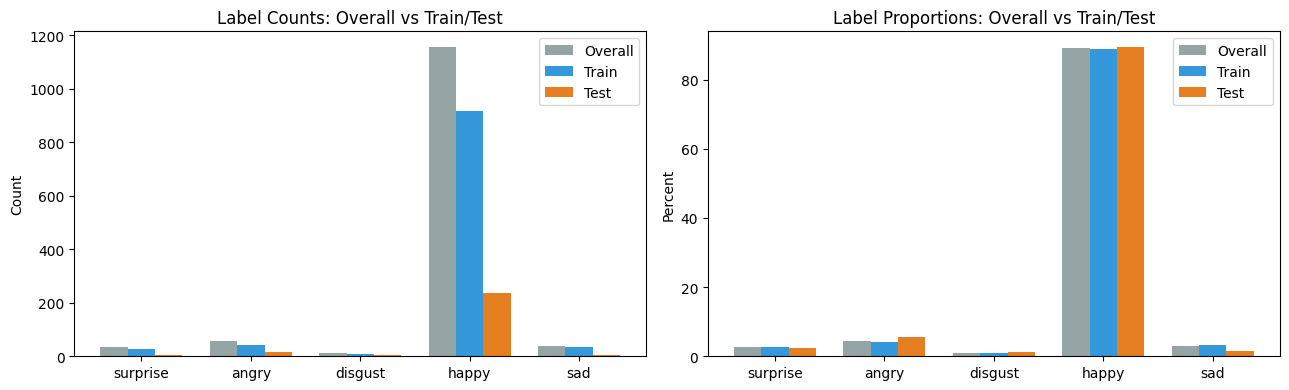

In [1]:
# 可复现实验入口
script_path = '二次核对项目/sanity_check_baseline.py'
summary_path = '二次核对项目/sanity_check_summary.md'
output_dir = '输出/sanity_check'
print(script_path)
print(summary_path)
print(output_dir)


二次核对项目/sanity_check_baseline.py
二次核对项目/sanity_check_summary.md
输出/sanity_check
